In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from environment.retail_env import RetailEnv
from agents.dqn.dqn_agent import DQNAgent
from agents.ppo.ppo_agent import PPOAgent
from agents.a2c.a2c_agent import A2CAgent
from agents.qtable.qtable_agent import QTableAgent
from agents.baselines.baseline_agents import RandomAgent, FixedMarginAgent, AlwaysCheapestAgent
from utils.trainer import Trainer

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)
print("Ready")

Ready


In [2]:
# DQN — slower decay, more exploration
dqn_cfg = {
    'lr':             3e-5,      # was 1e-4, slower updates
    'gamma':          0.99,
    'batch_size':     128,
    'min_buffer':     500,
    'epsilon_start':  1.0,
    'epsilon_end':    0.10,      # was 0.05, keep more exploration
    'epsilon_decay':  50000,     # was 5000, much slower decay
    'buffer_size':    50000,
    'target_update':  1000,      # was 500
}

# PPO — same, working well
ppo_cfg = {
    'lr':          2e-4,
    'gamma':       0.99,
    'rollout_len': 64,
    'batch_size':  32,
    'n_epochs':    4,
    'clip_eps':    0.2,
    'ent_coef':    0.05,         # higher entropy = more exploration
}

# A2C — slower lr, more entropy
a2c_cfg = {
    'lr':        3e-4,           # was 7e-4
    'gamma':     0.99,
    'n_steps':   20,             # was 5, longer horizon
    'ent_coef':  0.05,           # was 0.01, more exploration
}

# QTable — same, working fine
qtab_cfg = {
    'lr':            0.05,       # was 0.1, slower updates
    'gamma':         0.99,
    'epsilon_start': 1.0,
    'epsilon_end':   0.05,
    'epsilon_decay': 20000,      # was 5000
}

In [3]:
N_EPISODES = 500    # small test run first
CUSTOMERS  = 2000

env = RetailEnv()
env.demand.base_daily_customers = CUSTOMERS

dqn_cfg  = {'lr': 3e-5, 'gamma': 0.99, 'batch_size': 128, 'min_buffer': 500,
             'epsilon_start': 1.0, 'epsilon_end': 0.10, 'epsilon_decay': 50000,
             'buffer_size': 50000, 'target_update': 1000}
ppo_cfg  = {'lr': 2e-4, 'gamma': 0.99, 'rollout_len': 64, 'batch_size': 32,
             'n_epochs': 4, 'clip_eps': 0.2, 'ent_coef': 0.05}
a2c_cfg  = {'lr': 3e-4, 'gamma': 0.99, 'n_steps': 20, 'ent_coef': 0.05}
qtab_cfg = {'lr': 0.05, 'gamma': 0.99, 'epsilon_start': 1.0,
             'epsilon_end': 0.05, 'epsilon_decay': 20000}

agents = {
    # original 4 RL agents
    'walmart':      DQNAgent(0,  'walmart',      716, 50, 'pure_revenue',            dqn_cfg,  seed=42),
    'target':       PPOAgent(1,  'target',        716, 50, 'profit_margin',           ppo_cfg,  seed=42),
    'amazon_fresh': A2CAgent(2,  'amazon_fresh',  716, 50, 'market_share',            a2c_cfg,  seed=42),
    'qfc':          QTableAgent(3,'qfc',           716, 50, 'revenue_with_inventory',  qtab_cfg, seed=42),
    # new RL agents replacing rule-based
    'safeway':      PPOAgent(4,  'safeway',       716, 50, 'long_term_value',         ppo_cfg,  seed=43),
    'kroger':       A2CAgent(5,  'kroger',        716, 50, 'promo_aware_profit',      a2c_cfg,  seed=43),
    'trader_joes':  DQNAgent(6,  'trader_joes',   716, 50, 'premium_floor',           dqn_cfg,  seed=43),
    'whole_foods':  PPOAgent(7,  'whole_foods',   716, 50, 'prestige_reward',         ppo_cfg,  seed=44),
    'aldi':         A2CAgent(8,  'aldi',          716, 50, 'discount_maximization',   a2c_cfg,  seed=44),
    'costco':       QTableAgent(9,'costco',        716, 50, 'bulk_volume',             qtab_cfg, seed=44),
}

trainer = Trainer(env, agents,
                  checkpoint_dir=Path("../checkpoints"),
                  save_every=5)
print(f"All 10 agents are RL agents")
print(f"Training {N_EPISODES} episodes × 365 days × {CUSTOMERS} customers")
for name, agent in agents.items():
    print(f"  {name:<15} {agent.__class__.__name__:<12} reward={agent.reward_fn}")

2026-03-02 21:38:58 | INFO     | environment.demand_model | MNLDemandModel (basket-level) initialized | customers=10000 | price_sensitivity=2.5 | brand_loyalty=0.59 | mean_basket_size=10
2026-03-02 21:38:58 | INFO     | environment.inventory | InventoryManager initialized | agents=10 | products=50 | initial_stock=500 | reorder_point=100
2026-03-02 21:38:58 | INFO     | environment.supply_chain | SupplyChain initialized | lead_time=2-7 days | disruption_prob=0.0001
2026-03-02 21:38:58 | INFO     | environment.promotions | PromotionCalendar initialized | 11 promo windows | weekend_multiplier=1.347
2026-03-02 21:38:58 | INFO     | environment.retail_env | RetailEnv initialized | agents=10 | products=50 | obs_size=716 | episode_length=365
2026-03-02 21:38:58 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 21:38:58 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 21:38:58 | INFO 

In [4]:
obs_dict, _ = env.reset()
for agent_name in env.agent_iter():
    obs, reward, term, trunc, info = env.last()
    if term or trunc:
        env.step(None)
        continue
    action = agents[agent_name].act(obs)
    env.step(action)
print("One episode completed successfully")

One episode completed successfully


In [5]:
results = trainer.train(n_episodes=5)

# check RL agents are actually learning
print(f"DQN epsilon:    {agents['walmart'].epsilon:.4f}  (should be < 1.0)")
print(f"DQN buffer:     {len(agents['walmart'].buffer)}  (should be > 0)")
print(f"DQN steps:      {agents['walmart'].total_steps}")
print(f"PPO rollout:    {len(agents['target'].rollout['rewards'])}  (fills up to 128)")
print(f"A2C buffer:     {len(agents['amazon_fresh'].buf['rewards'])}")

# check revenues are non-zero and different across agents
for r in results:
    top = sorted(r.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"Ep {r.episode} top 3: {[(n, f'${v:,.0f}') for n,v in top]}")

2026-03-02 21:41:53 | INFO     | agents.base_agent.walmart | DQN saved to ../checkpoints/walmart
2026-03-02 21:41:53 | INFO     | agents.base_agent.walmart | DQN saved to ../checkpoints/walmart
2026-03-02 21:41:53 | INFO     | agents.base_agent.trader_joes | DQN saved to ../checkpoints/trader_joes
2026-03-02 21:41:53 | INFO     | agents.base_agent.trader_joes | DQN saved to ../checkpoints/trader_joes
2026-03-02 21:41:53 | INFO     | utils.trainer | Episode 5 | top agents: [('qfc', '$16,956,392'), ('costco', '$13,276,376'), ('walmart', '$12,220,173')]
DQN epsilon:    0.9606  (should be < 1.0)
DQN buffer:     1820  (should be > 0)
DQN steps:      2190
PPO rollout:    0  (fills up to 128)
A2C buffer:     0
Ep 0 top 3: [('costco', '$8,726,701'), ('qfc', '$7,129,592'), ('trader_joes', '$6,674,081')]
Ep 1 top 3: [('trader_joes', '$10,516,510'), ('walmart', '$10,152,712'), ('safeway', '$9,847,422')]
Ep 2 top 3: [('costco', '$17,368,864'), ('trader_joes', '$14,402,111'), ('walmart', '$12,835,4

In [30]:
import time

start = time.time()
results = []

for episode in range(N_EPISODES):
    ep_start = time.time()
    ep_results = trainer.train(n_episodes=1)
    results.extend(ep_results)
    ep_time = time.time() - ep_start
    elapsed = time.time() - start

    r = ep_results[0]
    top = sorted(r.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    top_str = ", ".join([f"{n}(${v:,.0f})" for n, v in top])

    rl_revs = {n: r.revenues.get(n, 0)
               for n in ['walmart','target','amazon_fresh','qfc']}
    rl_str = " | ".join([f"{n[:3]}=${v:,.0f}" for n, v in rl_revs.items()])

    eta = (elapsed / (episode + 1)) * (N_EPISODES - episode - 1)
    print(
        f"Ep {episode+1:>2}/{N_EPISODES} "
        f"[{ep_time:.1f}s, ETA {eta:.0f}s] "
        f"Top: {top_str}"
    )
    print(f"         RL: {rl_str}")

total = time.time() - start
print(f"\nDone! {total:.1f}s total ({total/N_EPISODES:.1f}s/episode)")

# verify RL agents are actually learning
from agents.dqn.dqn_agent import DQNAgent
from agents.qtable.qtable_agent import QTableAgent

walmart = agents['walmart']
qfc     = agents['qfc']

print(f"\nLearning verification:")
print(f"  DQN epsilon:      {walmart.epsilon:.4f} (should be < 1.0)")
print(f"  DQN buffer size:  {len(walmart.buffer)} (should be > 0)")
print(f"  DQN total steps:  {walmart.total_steps}")
print(f"  QTable states:    {len(qfc.q_table)}")
print(f"  QTable epsilon:   {qfc.epsilon:.4f}")

Ep  1/500 [26.6s, ETA 13282s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 | tar=$6,259,295 | ama=$2,263,812 | qfc=$9,514,653
Ep  2/500 [27.5s, ETA 13486s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 | tar=$6,259,295 | ama=$2,263,812 | qfc=$9,514,653
Ep  3/500 [29.7s, ETA 13889s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 | tar=$6,259,295 | ama=$2,263,812 | qfc=$9,514,653
Ep  4/500 [29.2s, ETA 14014s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 | tar=$6,259,295 | ama=$2,263,812 | qfc=$9,514,653
Ep  5/500 [28.5s, ETA 14011s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 | tar=$6,259,295 | ama=$2,263,812 | qfc=$9,514,653
Ep  6/500 [28.1s, ETA 13964s] Top: qfc($9,514,653), costco($7,147,847), trader_joes($7,016,562)
         RL: wal=$6,496,968 |

In [34]:
rows = []
for r in results:
    for agent_name in agents:
        rows.append({
            'episode':      r.episode,
            'agent':        agent_name,
            'revenue':      r.revenues.get(agent_name, 0),
            'market_share': r.market_shares.get(agent_name, 0),
            'reward':       r.total_rewards.get(agent_name, 0),
            'agent_type':   'RL',  # all agents are RL now
            'algorithm':    agents[agent_name].__class__.__name__,
            'reward_fn':    agents[agent_name].reward_fn,
        })

df = pd.DataFrame(rows)
print(df.groupby(['agent','algorithm','reward_fn'])['revenue'].mean().sort_values(ascending=False).round(0))

agent         algorithm    reward_fn             
qfc           QTableAgent  revenue_with_inventory    13048751.0
whole_foods   PPOAgent     prestige_reward            9028481.0
target        PPOAgent     profit_margin              8730328.0
safeway       PPOAgent     long_term_value            8695509.0
costco        QTableAgent  bulk_volume                8271250.0
trader_joes   DQNAgent     premium_floor              1516865.0
walmart       DQNAgent     pure_revenue               1443585.0
amazon_fresh  A2CAgent     market_share                733282.0
kroger        A2CAgent     promo_aware_profit          381714.0
aldi          A2CAgent     discount_maximization       300010.0
Name: revenue, dtype: float64


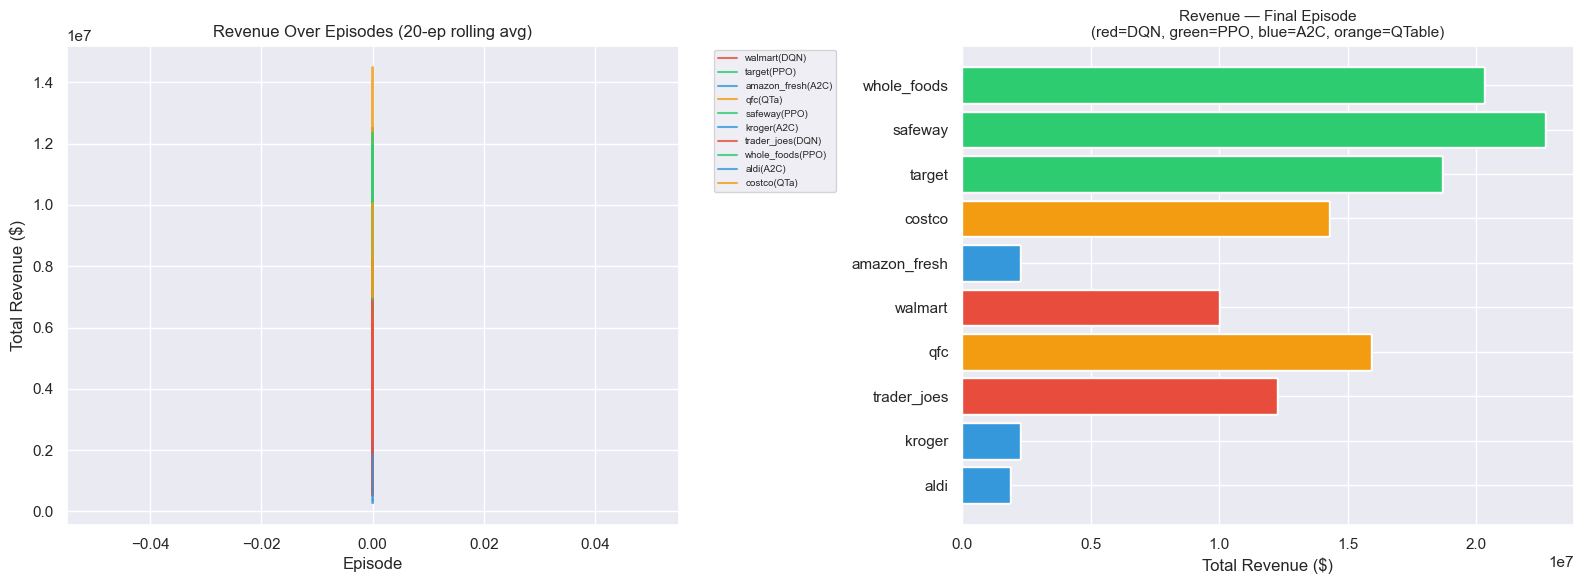

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# build episode-level df directly from results list
ep_rows = []
for r in results:
    for agent_name in agents:
        ep_rows.append({
            'episode':   r.episode,
            'agent':     agent_name,
            'revenue':   r.revenues.get(agent_name, 0),
            'market_share': r.market_shares.get(agent_name, 0),
            'algorithm': agents[agent_name].__class__.__name__,
        })
ep_df = pd.DataFrame(ep_rows)

ax = axes[0]
colors_map = {'DQNAgent': '#e74c3c', 'PPOAgent': '#2ecc71',
              'A2CAgent': '#3498db', 'QTableAgent': '#f39c12'}

for agent_name in agents:
    algo = agents[agent_name].__class__.__name__
    d = ep_df[ep_df['agent']==agent_name].sort_values('episode')['revenue']
    smoothed = d.rolling(20, min_periods=1).mean()
    ax.plot(ep_df[ep_df['agent']==agent_name].sort_values('episode')['episode'],
            smoothed, label=f"{agent_name}({algo[:3]})",
            color=colors_map[algo], linewidth=1.5, alpha=0.8)

ax.set_title("Revenue Over Episodes (20-ep rolling avg)", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Total Revenue ($)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

# Final episode bar chart
ax = axes[1]
final_ep = ep_df[ep_df['episode']==ep_df['episode'].max()].sort_values('revenue', ascending=True)
colors = [colors_map[agents[n].__class__.__name__] for n in final_ep['agent']]
ax.barh(final_ep['agent'], final_ep['revenue'], color=colors)
ax.set_title("Revenue — Final Episode\n(red=DQN, green=PPO, blue=A2C, orange=QTable)", fontsize=11)
ax.set_xlabel("Total Revenue ($)")

plt.tight_layout()
plt.savefig("../docs/training_revenue.png", dpi=150)
plt.show()

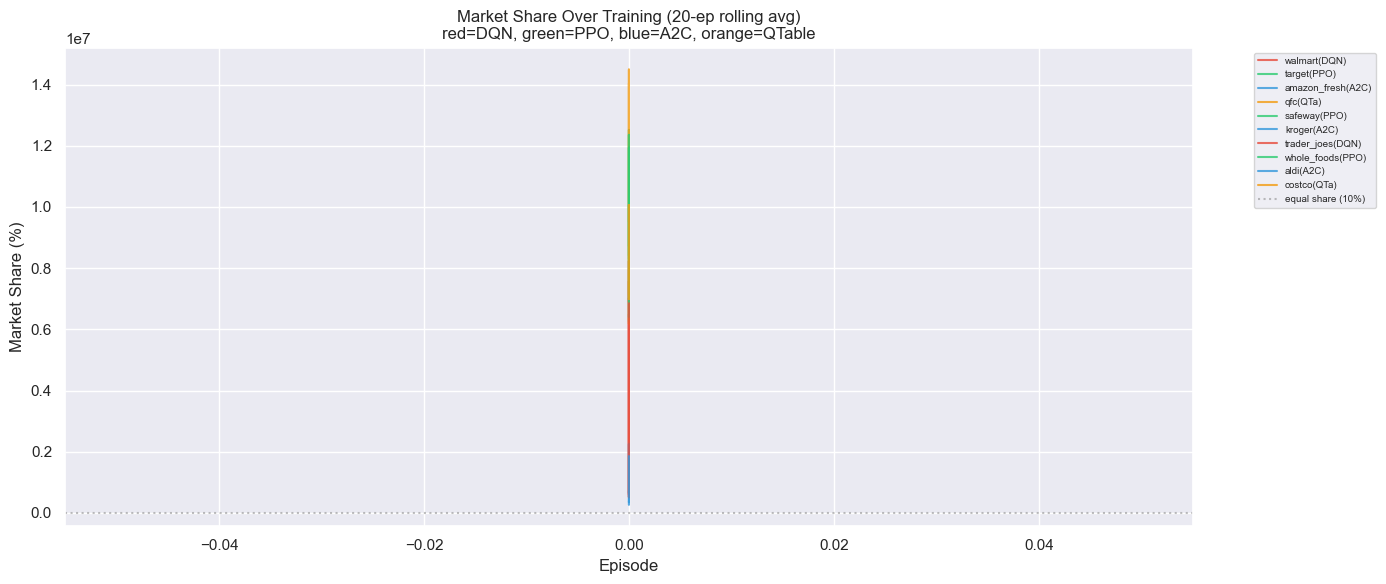

In [40]:
fig, ax = plt.subplots(figsize=(14, 6))

ep_ms = ep_df.copy()

colors_map = {'DQNAgent': '#e74c3c', 'PPOAgent': '#2ecc71',
              'A2CAgent': '#3498db', 'QTableAgent': '#f39c12'}

for agent_name in agents:
    algo = agents[agent_name].__class__.__name__
    d = ep_df[ep_df['agent']==agent_name].sort_values('episode')['revenue']
    smoothed = d.rolling(20, min_periods=1).mean()
    ax.plot(ep_df[ep_df['agent']==agent_name].sort_values('episode')['episode'],
            smoothed, label=f"{agent_name}({algo[:3]})",
            color=colors_map[algo], linewidth=1.5, alpha=0.8)

ax.axhline(10, color='gray', linestyle=':', alpha=0.5, label='equal share (10%)')
ax.set_title("Market Share Over Training (20-ep rolling avg)\nred=DQN, green=PPO, blue=A2C, orange=QTable", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Market Share (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig("../docs/training_market_share.png", dpi=150)
plt.show()

In [13]:
N_EPISODES = 200
CUSTOMERS  = 2000   # reduced for speed, still meaningful

env = RetailEnv()
env.demand.base_daily_customers = CUSTOMERS

dqn_cfg  = {'lr': 1e-4, 'gamma': 0.99, 'batch_size': 128,
             'min_buffer': 200, 'epsilon_decay': 5000,
             'buffer_size': 20000}
ppo_cfg  = {'lr': 3e-4, 'gamma': 0.99, 'rollout_len': 50,
             'batch_size': 25, 'n_epochs': 3, 'clip_eps': 0.2}
a2c_cfg  = {'lr': 7e-4, 'gamma': 0.99, 'n_steps': 10}
qtab_cfg = {'lr': 0.1,  'gamma': 0.99, 'epsilon_decay': 3000}

agents = {
    'walmart':      DQNAgent(0,  'walmart',      266, 50, 'pure_revenue',            dqn_cfg,  seed=42),
    'target':       PPOAgent(1,  'target',        266, 50, 'profit_margin',           ppo_cfg,  seed=42),
    'amazon_fresh': A2CAgent(2,  'amazon_fresh',  266, 50, 'market_share',            a2c_cfg,  seed=42),
    'qfc':          QTableAgent(3,'qfc',           266, 50, 'revenue_with_inventory',  qtab_cfg, seed=42),
    'safeway':      RandomAgent(4,  'safeway',      50),
    'kroger':       RandomAgent(5,  'kroger',       50),
    'trader_joes':  FixedMarginAgent(6,  'trader_joes',  50),
    'whole_foods':  FixedMarginAgent(7,  'whole_foods',  50),
    'aldi':         AlwaysCheapestAgent(8, 'aldi',   50),
    'costco':       RandomAgent(9,  'costco',       50),
}

trainer = Trainer(env, agents,
                  checkpoint_dir=Path("../checkpoints"),
                  save_every=10)
print(f"Training {N_EPISODES} episodes × 365 days × {CUSTOMERS} customers")
print(f"RL agents: walmart(DQN), target(PPO), amazon_fresh(A2C), qfc(QTable)")

2026-03-02 01:10:36 | INFO     | environment.demand_model | MNLDemandModel (basket-level) initialized | customers=10000 | price_sensitivity=2.5 | brand_loyalty=0.59 | mean_basket_size=10
2026-03-02 01:10:36 | INFO     | environment.inventory | InventoryManager initialized | agents=10 | products=50 | initial_stock=500 | reorder_point=100
2026-03-02 01:10:36 | INFO     | environment.supply_chain | SupplyChain initialized | lead_time=2-7 days | disruption_prob=0.0001
2026-03-02 01:10:36 | INFO     | environment.promotions | PromotionCalendar initialized | 11 promo windows | weekend_multiplier=1.347
2026-03-02 01:10:36 | INFO     | environment.retail_env | RetailEnv initialized | agents=10 | products=50 | obs_size=266 | episode_length=365
2026-03-02 01:10:36 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 01:10:36 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 01:10:36 | INFO 

In [14]:
import time

start = time.time()
results = []

for episode in range(N_EPISODES):
    ep_start = time.time()
    ep_results = trainer.train(n_episodes=1)
    results.extend(ep_results)
    ep_time = time.time() - ep_start
    elapsed = time.time() - start

    r = ep_results[0]
    top = sorted(r.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    top_str = ", ".join([f"{n}(${v:,.0f})" for n, v in top])

    rl_revs = {n: r.revenues.get(n, 0)
               for n in ['walmart','target','amazon_fresh','qfc']}
    rl_str = " | ".join([f"{n[:3]}=${v:,.0f}" for n, v in rl_revs.items()])

    eta = (elapsed / (episode + 1)) * (N_EPISODES - episode - 1)
    print(
        f"Ep {episode+1:>2}/{N_EPISODES} "
        f"[{ep_time:.1f}s, ETA {eta:.0f}s] "
        f"Top: {top_str}"
    )
    print(f"         RL: {rl_str}")

total = time.time() - start
print(f"\nDone! {total:.1f}s total ({total/N_EPISODES:.1f}s/episode)")

# verify RL agents are actually learning
from agents.dqn.dqn_agent import DQNAgent
from agents.qtable.qtable_agent import QTableAgent

walmart = agents['walmart']
qfc     = agents['qfc']

print(f"\nLearning verification:")
print(f"  DQN epsilon:      {walmart.epsilon:.4f} (should be < 1.0)")
print(f"  DQN buffer size:  {len(walmart.buffer)} (should be > 0)")
print(f"  DQN total steps:  {walmart.total_steps}")
print(f"  QTable states:    {len(qfc.q_table)}")
print(f"  QTable epsilon:   {qfc.epsilon:.4f}")

Ep  1/200 [26.7s, ETA 5313s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$702,417 | qfc=$5,635,035
Ep  2/200 [27.1s, ETA 5325s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$702,417 | qfc=$5,635,035
Ep  3/200 [27.1s, ETA 5314s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$702,417 | qfc=$5,635,035
Ep  4/200 [27.3s, ETA 5302s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$702,417 | qfc=$5,635,035
Ep  5/200 [27.8s, ETA 5305s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$702,417 | qfc=$5,635,035
Ep  6/200 [1014.2s, ETA 37191s] Top: aldi($7,651,324), qfc($5,635,035), whole_foods($5,468,559)
         RL: wal=$4,566,036 | tar=$4,776,498 | ama=$70

In [31]:
rows = []
for r in results:
    for agent_name in agents:
        rows.append({ 
            'episode':       r.episode,
            'agent':         agent_name,
            'revenue':       r.revenues.get(agent_name, 0),
            'market_share':  r.market_shares.get(agent_name, 0),
            'reward':        r.total_rewards.get(agent_name, 0),
            'agent_type':    ('RL' if agent_name in
                             ['walmart','target','amazon_fresh','qfc']
                             else 'Rule-Based'),
        })

df = pd.DataFrame(rows)
print(df.groupby(['agent','agent_type'])['revenue'].mean().sort_values(ascending=False).round(0))

agent         agent_type
qfc           RL            13048751.0
whole_foods   Rule-Based     9028481.0
target        RL             8730328.0
safeway       Rule-Based     8695509.0
costco        Rule-Based     8271250.0
trader_joes   Rule-Based     1516865.0
walmart       RL             1443585.0
amazon_fresh  RL              733282.0
kroger        Rule-Based      381714.0
aldi          Rule-Based      300010.0
Name: revenue, dtype: float64


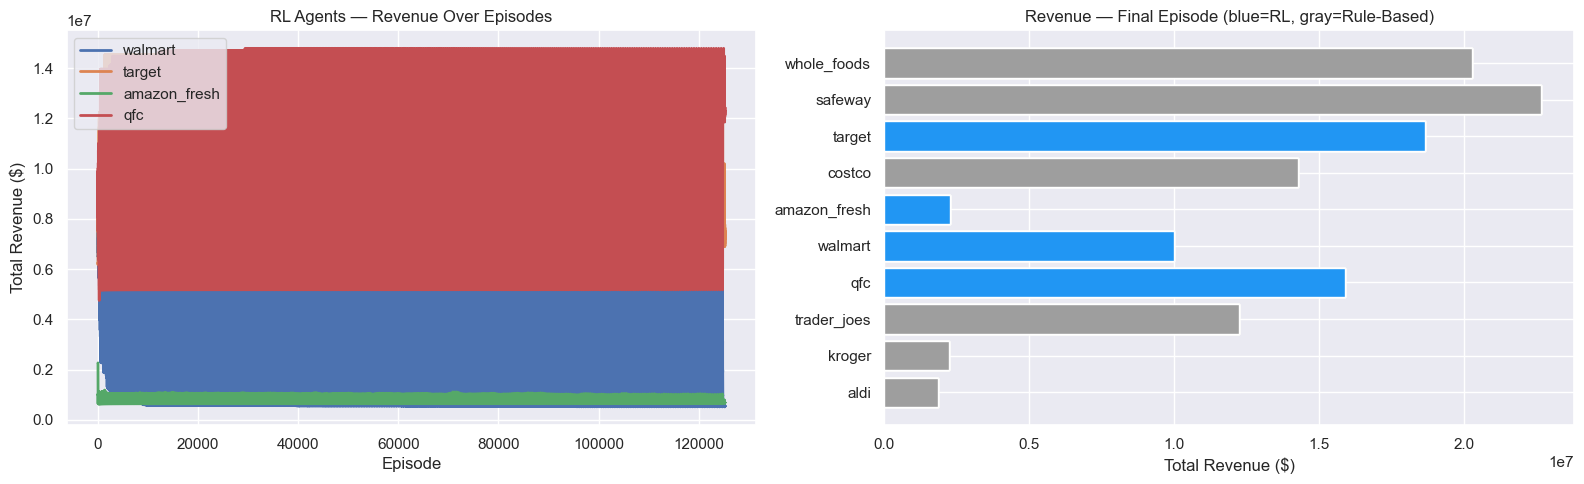

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RL agents
ax = axes[0]
rl_agents = ['walmart', 'target', 'amazon_fresh', 'qfc']
for agent in rl_agents:
    d = df[df['agent']==agent]['revenue']
    smoothed = d.rolling(5, min_periods=1).mean()
    ax.plot(range(len(d)), smoothed, label=agent, linewidth=2)
ax.set_title("RL Agents — Revenue Over Episodes", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Total Revenue ($)")
ax.legend()

# All agents final episode
ax = axes[1]
final = df[df['episode']==df['episode'].max()]
final_sorted = final.sort_values('revenue', ascending=True)
colors = ['#2196F3' if t=='RL' else '#9E9E9E'
          for t in final_sorted['agent_type']]
ax.barh(final_sorted['agent'], final_sorted['revenue'], color=colors)
ax.set_title(f"Revenue — Final Episode (blue=RL, gray=Rule-Based)", fontsize=12)
ax.set_xlabel("Total Revenue ($)")

plt.tight_layout()
plt.savefig("../docs/training_revenue.png", dpi=150)
plt.show()

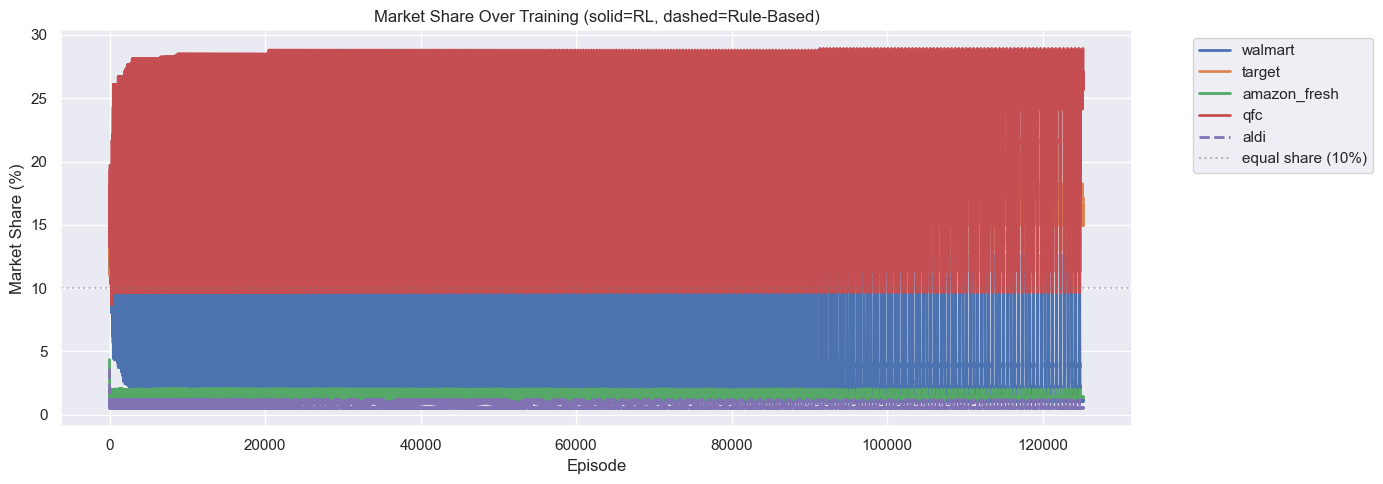

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
for agent in ['walmart', 'target', 'amazon_fresh', 'qfc', 'aldi']:
    d = df[df['agent']==agent]['market_share'] * 100
    smoothed = d.rolling(5, min_periods=1).mean()
    style = '-' if agent in rl_agents else '--'
    ax.plot(range(len(d)), smoothed, label=agent,
            linewidth=2, linestyle=style)

ax.axhline(10, color='gray', linestyle=':', alpha=0.5, label='equal share (10%)')
ax.set_title("Market Share Over Training (solid=RL, dashed=Rule-Based)", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Market Share (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../docs/training_market_share.png", dpi=150)
plt.show()

In [26]:
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Episodes trained: {N_EPISODES}")
print(f"Days per episode: 365")
print(f"Customers/day:    {CUSTOMERS}")
print()

# use results list directly — it has one entry per episode
first5_results = results[:5]
last5_results  = results[-5:]

def avg_revenue(result_list, agent_name):
    return np.mean([r.revenues.get(agent_name, 0) for r in result_list])

print(f"{'Agent':<15} {'Avg Rev (ep1-5)':>16} {'Avg Rev (last 5)':>17} {'Change':>10}")
print("-" * 62)
for agent in ['walmart','target','amazon_fresh','qfc','aldi','random_avg']:
    if agent == 'random_avg':
        r1 = np.mean([avg_revenue(first5_results, n) for n in ['safeway','kroger','costco']])
        r2 = np.mean([avg_revenue(last5_results,  n) for n in ['safeway','kroger','costco']])
        name = 'random (avg)'
    else:
        r1   = avg_revenue(first5_results, agent)
        r2   = avg_revenue(last5_results,  agent)
        name = agent
    change = ((r2 - r1) / r1 * 100) if r1 > 0 else 0
    marker = '↑' if change > 5 else ('↓' if change < -5 else '→')
    print(f"{name:<15} ${r1:>14,.0f}   ${r2:>14,.0f}   {marker}{abs(change):>6.1f}%")
print("=" * 60)

TRAINING SUMMARY
Episodes trained: 20
Days per episode: 365
Customers/day:    1000

Agent            Avg Rev (ep1-5)  Avg Rev (last 5)     Change
--------------------------------------------------------------
walmart         $     3,265,196   $     3,164,071   →   3.1%
target          $     3,055,891   $     4,571,490   ↑  49.6%
amazon_fresh    $       760,228   $       332,480   ↓  56.3%
qfc             $     4,336,162   $     4,580,983   ↑   5.6%
aldi            $       578,662   $       161,603   ↓  72.1%
random (avg)    $     2,775,748   $     2,999,465   ↑   8.1%
